# Part 1 - From Ground Up (From Scratch)

In [65]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt

In [66]:
# Create sigmoid function
# A logistic function that maps any input values to a range of probabilities between 0 and 1
def sigmoid(z):
  return 1.0 / (1.0 + np.exp(-z))

In [67]:
# Create an objective function
# To calculate the loss / cost of the model
def CalcObj(xTrain, yTrain, wHat):
  
  # n is the number of training examples
  # Used to computer average loss
  n = len(yTrain)

  # np.c_ is used to concatenate arrays column-wise
  # Prepends a column of ones to xTrain to create bias (intercept)
  # x_bias = (n, d + 1)
  # To compute z with a single matrix multiply rather than handling bias separately
  x_bias = np.c_[np.ones(n), xTrain]

  # Matrix multiplication
  # z = (n, )
  z = x_bias @ wHat

  # Applies logistic (sigmoid) function to z
  # p is the predicted probability for label = (n, )
  # Values are between 0 and 1
  p = sigmoid(z)

  # Calculate the loss / cost of the model
  # Averaged over all examples
  obj = -1/n * np.sum(yTrain * np.log(p + 1e-10) + (1 - yTrain) * np.log(1 - p + 1e-10))

  return obj

In [68]:
# Create a gradient descent function
# To calculate how much each weight should be updated
# Make the prediction closer to actual answer
def CalcGrad(xTrain, yTrain, wHat):

  # n is the number of training examples
  # To average the results
  n = len(yTrain)

  # Same as before
  x_bias = np.c_[np.ones(n), xTrain]

  # Computes raw prediction before applying sigmoid
  # Each z is a weighted sum of inputs for one training example
  # The model 'confidence' before turning it into probabilities
  z = x_bias @ wHat

  # Applies sigmoid function to z
  # p is the predicted probability for label = (n, )
  # Values are between 0 and 1
  p = sigmoid(z)

  # Calculates gradient
  # The direction to move weights to reduce error
  # (p - yTrain) is how wrong each prediction was
  # If p > yTrain, prediction is too high
  # If p < yTrain, prediction is too low
  # x_bias.T @ (p - yTrain) multiplies error by input features
  # Which features contributed to the mistake and how much
  # The result (grad) is a vector of the same size as wHat
  # Showing "How much each weight is responsible for total error" 
  grad = 1 / n * x_bias.T @ (p - yTrain)

  return grad

In [69]:
# Create a update parameter function
def UpdateParams(weight, grad, lr):

  # The new weight to update the model
  new_weight = weight - lr * grad

  return new_weight

In [70]:
# Create a check convergence function
# Checks whether loss (objective) has stopped changing between two iterations of training
# tol = Tolerance (Small enough change) as threshold
def CheckConvg(oldObj, newObj, tol):
  
  # Compute absolute difference between old and new loss values and check if is smaller than tolerance
  abs_diff = abs(oldObj - newObj)

  # Is it small enough to stop learning
  convg = abs_diff < tol

  return convg

In [71]:
# Create a function to train a logistic model using gradient descent
# It looks at all training samples on each iteration
# Calculate average gradient
# Update model's weight until it stops improving
# Return wHat (final learned weights), objVals (a list tracking loss value over iterations) to plot or analyze convergence
def GradientDescent(xTrain, yTrain):
  
  # Define hyperparameters
  lr = 0.01
  tol = 0.001
  max_iter = 10000

  # Init parameters
  # Flat, untrained
  p = xTrain.shape[1] # Number of features (columns) in training data
  wHat = np.zeros(p + 1) # ALl weights start at 0

  # Track loss values
  # Monitor how the loss decreases as training goes on
  objVals = []
  oldObj = CalcObj(xTrain, yTrain, wHat)
  objVals.append(oldObj)

  # Main gradient descent loop
  # One iteration = One learning step
  for i in range(max_iter):

    # Use the current weights to compute how much each weight contributes to overall error
    # To tell the model which direction to move
    grad = CalcGrad(xTrain, yTrain, wHat)

    # Update the weights
    # Moves the weights in the opposite direction of gradient to reduce loss
    # Where learning happens
    wHat = UpdateParams(wHat, grad, lr)

    # Compute new loss
    newObj = CalcObj(xTrain, yTrain, wHat)
    objVals.append(newObj)

    # Saves computation and prevents overfitting
    # Smaller than tolerance means training has stabilized
    if CheckConvg(oldObj, newObj, tol):
      break

    # Update for next round
    oldObj = newObj

  return wHat, objVals

In [72]:
# Visualize the learning curve
def LearningCurve(xTrain, yTrain):
  w, losses = GradientDescent(xTrain, yTrain)

  plt.plot(losses)
  plt.title("Loss vs Iterations")
  plt.xlabel("Iteration")
  plt.ylabel("Objective Value")
  plt.show()

In [73]:
# Create a predict function
# Uses the learned weights
# To predict the probability that each test example belongs to class 1
# Convert probabilities into binary labels
# Compare to the true labels (yTest) to count how many predictions were wrong
def PredictLabels(xTest, yTest, wHat):

  # Number of test samples
  m = len(yTest)

  # Same as before
  x_bias = np.c_[np.ones(m), xTest]

  # Same as before
  # Compute the score for each test example
  z = x_bias @ wHat

  # Same as before
  # If p = 0.8, the model is 80% confidence is 1
  # If p = 0.3, the model is 30% confidence is 1
  p = sigmoid(z)

  # Convert probabilities into binary class predictions
  # Change it to 0.7 for stricter positive predictions
  yHat = (p > 0.5).astype(int)

  # Compares predicted labels (yHat) with true labels (yTest)
  # Count how many were incorrect
  numErrors = np.sum(yHat != yTest)

  return yHat, numErrors

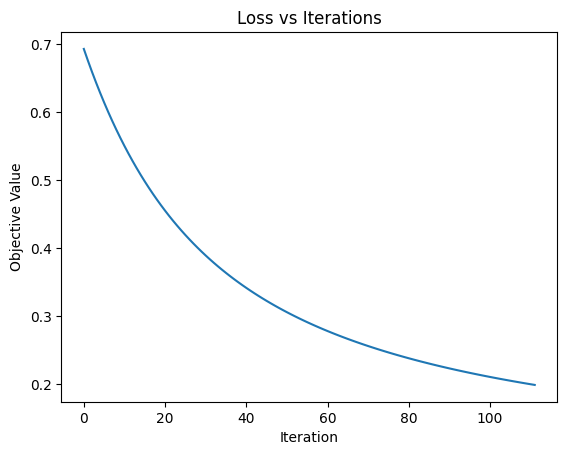

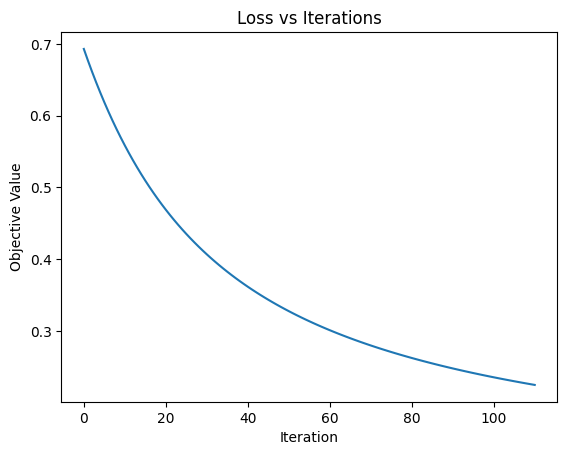

Scratch Model Accuracy: 0.95


In [74]:
# Time to train model
train_data = np.loadtxt('train_toydata.txt', delimiter = '\t')
xTrain = train_data[:, :2]
yTrain = train_data[:, 2]

LearningCurve(xTrain, yTrain)

test_data = np.loadtxt('test_toydata.txt', delimiter = '\t')
xTest = test_data[:, :2]
yTest = test_data[:, 2]

LearningCurve(xTest, yTest)

wHat, objVals = GradientDescent(xTrain, yTrain)
yHat_scratch, numErrors_scratch = PredictLabels(xTest, yTest, wHat)
acc_scratch = 1 - numErrors_scratch / len(yTest)
print(f'Scratch Model Accuracy: {acc_scratch}')

In [75]:
# Function to predict on custom inputs
def PredictCustomInputs(custom_inputs, wHat):

  # Add bias term (column of ones)
  n_samples = custom_inputs.shape[0]
  x_bias = np.c_[np.ones(n_samples), custom_inputs]
  
  # Compute raw scores
  z = x_bias @ wHat
  
  # Apply sigmoid to get probabilities
  probabilities = sigmoid(z)
  
  # Convert to binary predictions (threshold = 0.5)
  predictions = (probabilities > 0.5).astype(int)
  
  return predictions, probabilities


In [76]:
# Train the model
wHat, objVals = GradientDescent(xTrain, yTrain)

# Create a single data point
my_input = np.array([[1.5, 2.0]])  
prediction, probability = PredictCustomInputs(my_input, wHat)

print(f"Single prediction:")
print(f"Input: {my_input[0]}")
print(f"Predicted class: {prediction[0]}")
print(f"Probability: {probability[0]:.4f}")

# Create multiple data points
my_inputs = np.array([
	[1.0, 1.5],
	[2.0, 3.0],
	[0.5, 0.8]
])

predictions, probabilities = PredictCustomInputs(my_inputs, wHat)

print(f"\nMultiple predictions:")
for i in range(len(my_inputs)):
	print(f"Input {i + 1}: {my_inputs[i]} -> Class: {predictions[i]}, Probability: {probabilities[i]:.4f}")


Single prediction:
Input: [1.5 2. ]
Predicted class: 1
Probability: 0.8426

Multiple predictions:
Input 1: [1.  1.5] -> Class: 1, Probability: 0.7679
Input 2: [2. 3.] -> Class: 1, Probability: 0.9175
Input 3: [0.5 0.8] -> Class: 1, Probability: 0.6492


# Part 2 - Using PyTorch

In [77]:
# Import libraries
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

In [78]:
train_data = np.loadtxt('train_toydata.txt', delimiter = '\t')
xTrain = train_data[:, :2]
yTrain = train_data[:, 2]

test_data = np.loadtxt('test_toydata.txt', delimiter = '\t')
xTest = test_data[:, :2]
yTest = test_data[:, 2]

In [79]:
# Create a model
# y = mx + b, sigmoid at the end
class LogisticRegression(nn.Module):
	def __init__(self, input_size):
		super().__init__()

		# Creates a linear transformation
		# output = weight x input + bias
		# Here: 2 inputs -> 1 outputs
		self.linear = nn.Linear(input_size, 1, bias = True)

	def forward(self, x):

		# Squashes values to 0 - 1 range
		# Convert linear output to probability
		y_pred = torch.sigmoid(self.linear(x))
		return y_pred

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Convert NumPy arrays to PyTorch tensors
# Required for GPU/autograd (automatic differentiation engine that powers neural network training)
# .to(device) - Moves data/model to GPU if available
# .unsqueeze(1) - Adds dimension to make shape compatible: [N] -> [N, 1]
x_train_t = torch.from_numpy(xTrain).float().to(device)
y_train_t = torch.from_numpy(yTrain).float().unsqueeze(1).to(device)
x_test_t = torch.from_numpy(xTest).float().to(device)
y_test_t = torch.from_numpy(yTest).float().unsqueeze(1).to(device)

model = LogisticRegression(2).to(device)

# Direct access to parameters tensors
# Bypassing autograd tracking
# torch.zeros() - Create tensors filled with zeros
# Manually init weights and bias to zero before training starts
model.linear.weight.data = torch.zeros(1, 2).to(device)
model.linear.bias.data = torch.zeros(1).to(device)

# Binary Cross Entropy loss
# Measures how wrong prediction are for binary classification
criterion = nn.BCELoss()

# Stochastic Gradient Descent Optimizer
# Updates weights to minimize loss
optimizer = optim.SGD(model.parameters(), lr = 0.01)

num_epochs = 10000
prev_loss = float('inf') # Largest possible float value

training_loss = []

for epoch in range(num_epochs):

	# Clears old gradient before computing new ones
	optimizer.zero_grad()
	outputs = model(x_train_t)
	loss = criterion(outputs, y_train_t)

	# Computes gradients
	# How much each weight contributed to error
	loss.backward()

	# Updates weights using computed gradients
	optimizer.step()

	if abs(prev_loss - loss.item()) < 0.001:
		break
	
	prev_loss = loss.item()
	training_loss.append(loss.item())
	
	# print(f'Epoch: {epoch + 1}, Loss = {loss.item():.4f}')

# Disable gradient computation during evaluation
# Save memory/time
with torch.no_grad():
	outputs = model(x_test_t)

	# Converts probabilities to binary prediction (0/1)
	predicted = (outputs > 0.5).float()
	num_errors_pytorch = (predicted != y_test_t).sum().item()
	acc_pytorch = 1 - num_errors_pytorch / len(yTest)

print(f'PyTorch Model Accuracy: {acc_pytorch}')

PyTorch Model Accuracy: 0.95


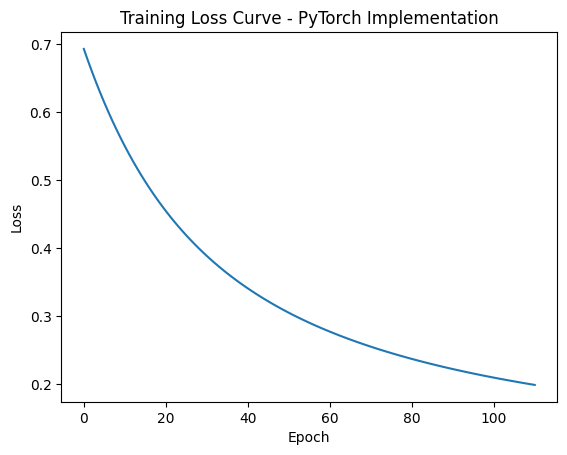

In [80]:
import matplotlib.pyplot as plt

plt.plot(training_loss, label = 'Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve - PyTorch Implementation')
plt.show()

# Final Results

In [81]:
print(f'Scratch Model Accuracy: {acc_scratch}')
print(f'PyTorch Model Accuracy: {acc_pytorch}')

Scratch Model Accuracy: 0.95
PyTorch Model Accuracy: 0.95
